__Librairy imports__

In [ ]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import seaborn as sns

from supervisedlearning.linearregression import LinRegression
from supervisedlearning.logisticregression import LogRegression
from supervisedlearning.neuralnetwork import NeuralNetwork
from unsupervisedlearning.kmeans import KMeans

from sklearn.datasets import load_iris, load_breast_cancer
from keras.datasets import mnist

__Importing Data__

In [10]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

In [14]:
# df = pd.get_dummies(housing, columns = ['ocean_proximity'], drop_first = True, dtype = int)
# df = df.dropna()
# train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 42)
# print(df.columns)
# rel = df[['median_house_value', 'median_income']]
print(1)

1


## __Supervised Learning__


### __Linear Regression__

Importing Linear Regression test data

In [15]:
ads = pd.read_csv('datasets/Advertising.csv')

# splitting into train and test set
train_set, test_set = train_test_split(ads, test_size = 0.2, random_state = 42)

In [16]:
# formatting a test value
def formatting_testing(test_set):
    testing_true_value = test_set.iloc[4]['sales']
    testing = test_set.drop(columns = 'sales').iloc[4]
    testing = testing.to_numpy()
    testing = np.insert(testing, 0, 1, axis=0)
    return testing, testing_true_value
testing, testing_true_value = formatting_testing(test_set)

RMSE of model is: 1.0699463759704548
Predicted value: 22.492917090721207 |  Actual value: 24.7


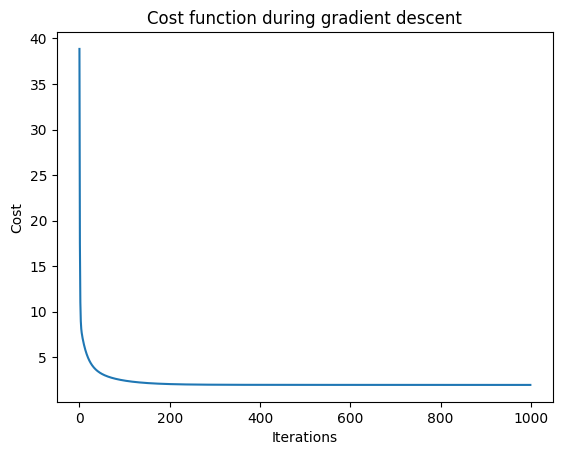

[0.02306793 0.05304381 0.21853934 0.02370923]


In [17]:
# creating our model
linR_model = LinRegression(
    trainset = train_set,
    testset = test_set,
    target = 'sales',
    learning_rate = 0.00005
    )

# applying our gradient descent
linR_model.gradientdescent()
print(f'RMSE of model is: {linR_model.RMSE_calculation()}')
print(f'Predicted value: {linR_model.make_prediction(testing)} | ', f'Actual value: {testing_true_value}')
linR_model.plot_error_function()
print(linR_model.theta)

Comparing with Scikit Learn's Linear Regression

In [18]:
# formatting data set to use scikit learns Linear Regression
comparative_x = ads.drop(columns = 'sales')
comparative_x = comparative_x.to_numpy()
comparative_x = np.insert(comparative_x, 0, 1, axis=1)
comparative_y = ads['sales'].to_numpy()

# splitting data
x_train, x_test, y_train, y_test = train_test_split(comparative_x, comparative_y, test_size= 0.2, random_state= 42)

# fitting out the model
comparative_model = LinearRegression()
comparative_model.fit(x_train, y_train)
y_train_pred = comparative_model.predict(x_train)
y_test_pred = comparative_model.predict(x_test)

# computing RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))


print(f'RMSE of Scikit Learns model: {rmse}')
print(f'Predicted value: {comparative_model.predict(testing.reshape(1, -1))[0]}')



RMSE of Scikit Learns model: 1.781599661533451
Predicted value: 22.11237325985766


### __Logistic Regression__

Importing iris dataset for logistic regression

In [2]:
# importing and formatting dataset
iris = load_iris(as_frame= True)
logistic_x = iris.data.values
logistic_y = iris.target_names[iris.target] == 'virginica'

# splitting
x_train_iris, x_test_iris, y_train_iris, y_test_iris = train_test_split(logistic_x, logistic_y, test_size= 0.2, random_state= 42)

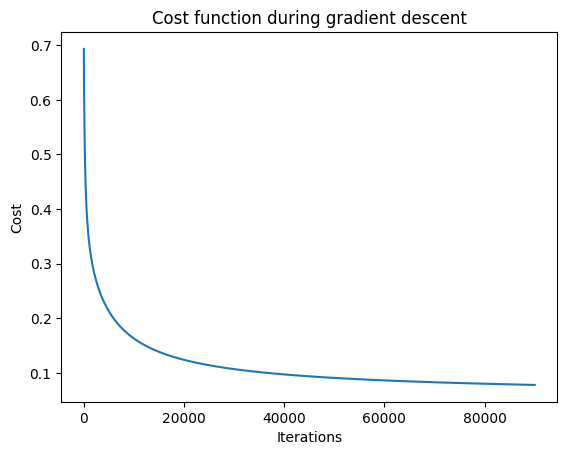

('TP', 'FP', 'FN', 'TN')
(11, 0, 0, 19)


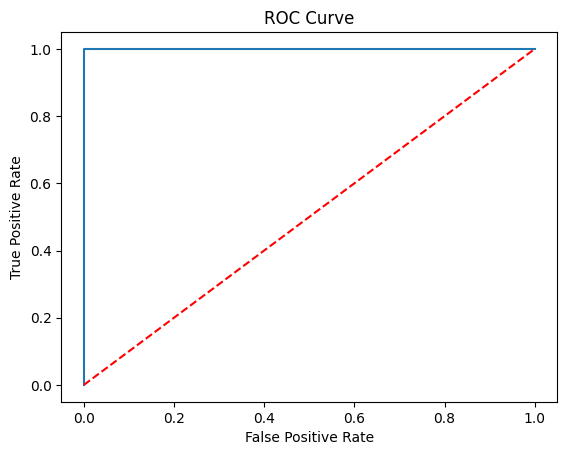

In [3]:
logistic_model_iris = LogRegression(
    train_x = x_train_iris,
    train_y = y_train_iris,
    test_x = x_test_iris,
    test_y = y_test_iris,
    learning_rate = 0.005,
    iterations = 90000
)
logistic_model_iris.gradientdescent()
logistic_model_iris.plot_error_function()
print(('TP', 'FP', 'FN', 'TN'))
print(logistic_model_iris.confusion_matrix(threshold = 0.5))
logistic_model_iris.ROC()


Application of model on cancer dataset

In [4]:
cancer = load_breast_cancer(as_frame = True)
cancer_x = cancer.data.values
cancer_y = np.array(cancer.target)

# splitting cancer dataset
x_train_cancer, x_test_cancer, y_train_cancer, y_test_cancer = train_test_split(cancer_x, cancer_y, test_size= 0.2, random_state= 42)

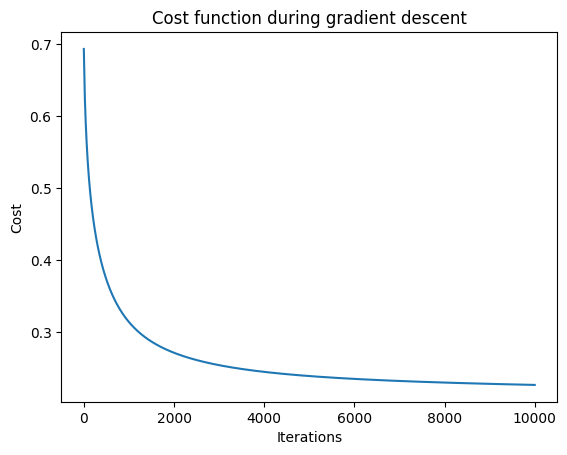

('TP', 'FP', 'FN', 'TN')
(71, 4, 0, 39)


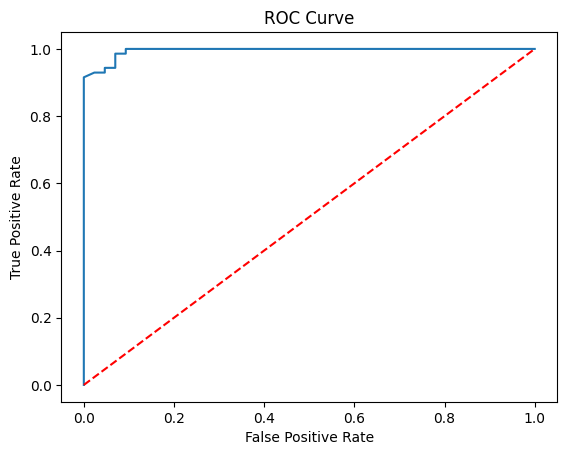

In [5]:
logistic_model_cancer = LogRegression(
    train_x = x_train_cancer,
    train_y = y_train_cancer,
    test_x = x_test_cancer,
    test_y = y_test_cancer,
    learning_rate = 0.000005,
    iterations = 10000
)

logistic_model_cancer.gradientdescent()
logistic_model_cancer.plot_error_function()
print(('TP', 'FP', 'FN', 'TN'))
print(logistic_model_cancer.confusion_matrix(threshold = 0.5))
logistic_model_cancer.ROC()

Application of model on housing dataset

In [26]:
# formatting housing dataset

format_logi_housing = housing.dropna()

h_logi_x = format_logi_housing.drop(columns = ['ocean_proximity', 'median_house_value'])
h_logi_x = h_logi_x.to_numpy()

h_logi_y = format_logi_housing['median_house_value']
h_logi_y = h_logi_y.to_numpy()
h_logi_y = (h_logi_y >= np.median(h_logi_y)).astype(int)


x_train_h, x_test_h, y_train_h, y_test_h = train_test_split(h_logi_x, h_logi_y, test_size= 0.2, random_state= 42)

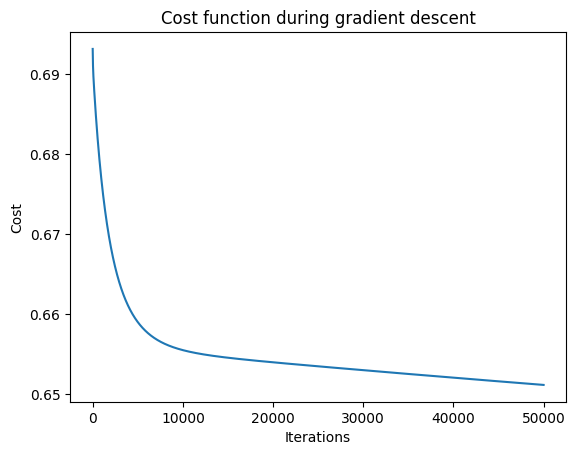

('TP', 'FP', 'FN', 'TN')
(1468, 835, 595, 1189)


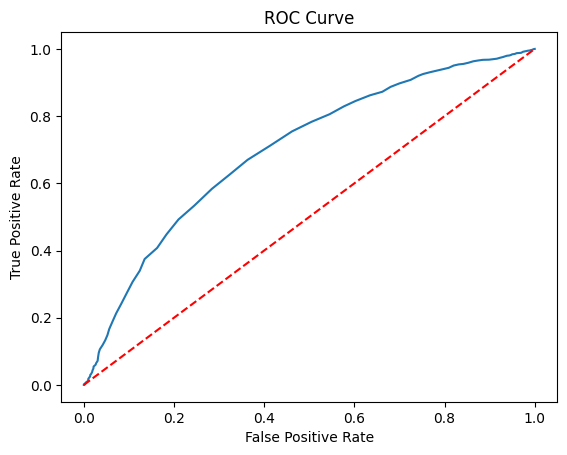

In [31]:
logistic_model_housing = LogRegression(
    train_x = x_train_h,
    train_y = y_train_h,
    test_x = x_test_h,
    test_y = y_test_h,
    learning_rate = 0.000000005,
    iterations = 50000
)

logistic_model_housing.gradientdescent()
logistic_model_housing.plot_error_function()
print(('TP', 'FP', 'FN', 'TN'))
print(logistic_model_housing.confusion_matrix(threshold = 0.5))
logistic_model_housing.ROC()

In [8]:
NN_model = NeuralNetwork(
    
)

5


## __Unsupervised Learning__


### __K means clustering__

Importing k means test data

In [32]:
data = load_iris()

x = data.data
y = data.target
x_2d = x[:,:3]


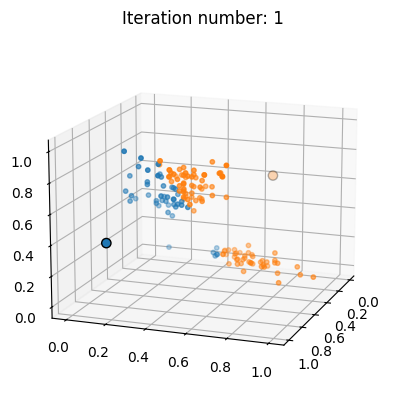

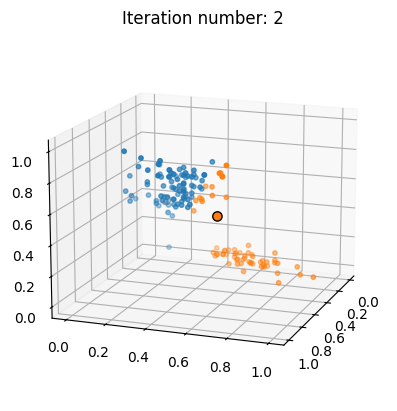

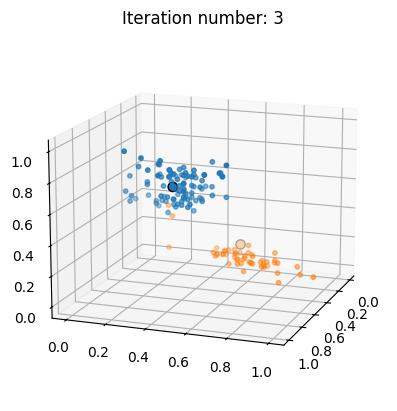

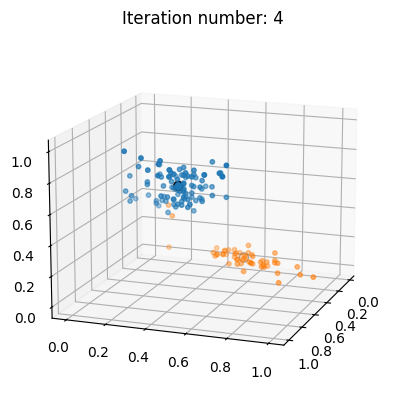

In [33]:
# Applying our k means model for the iris model
kmeans_iris = KMeans(data = x_2d, k = 2)

#applying our clustering
kmeans_iris.algorithm()

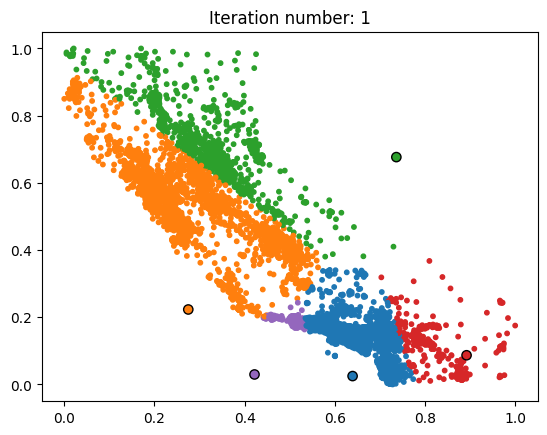

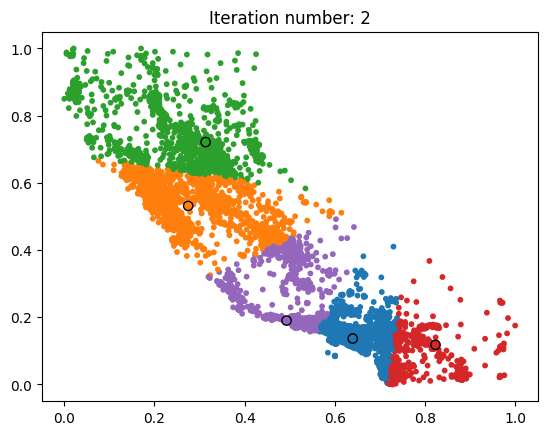

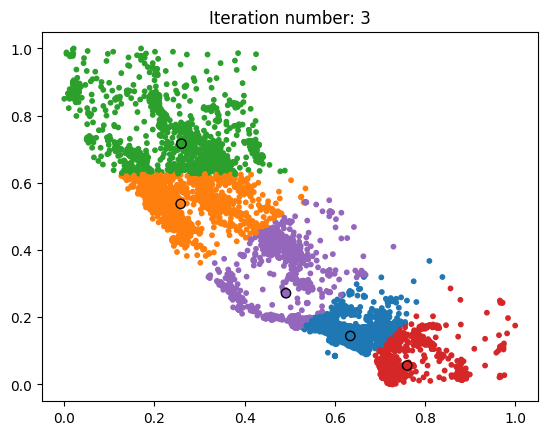

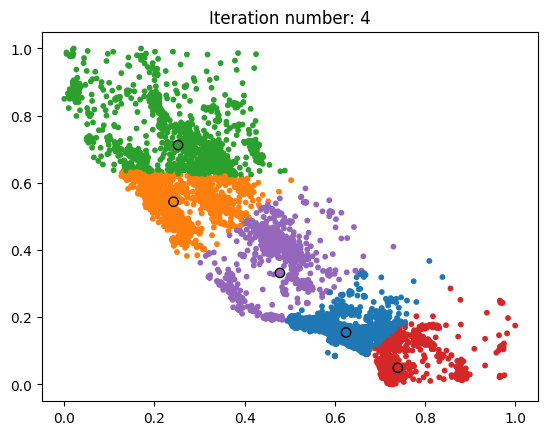

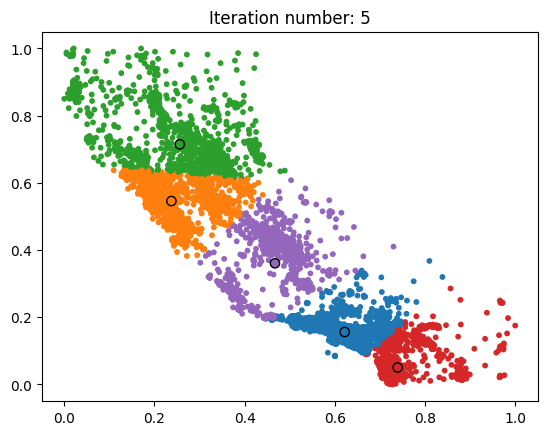

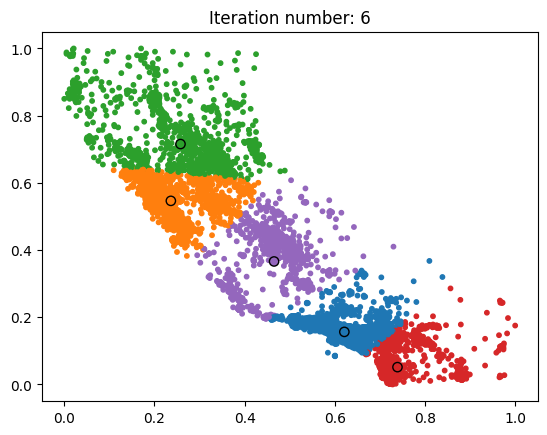

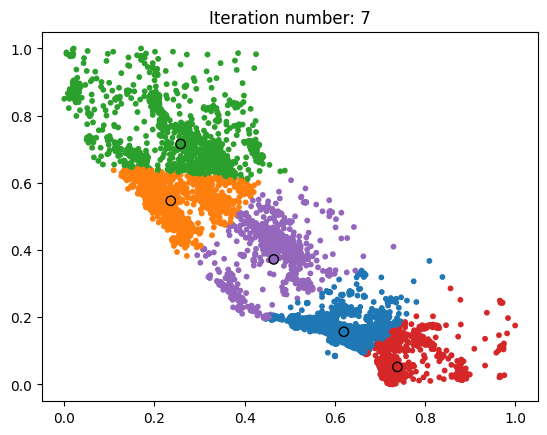

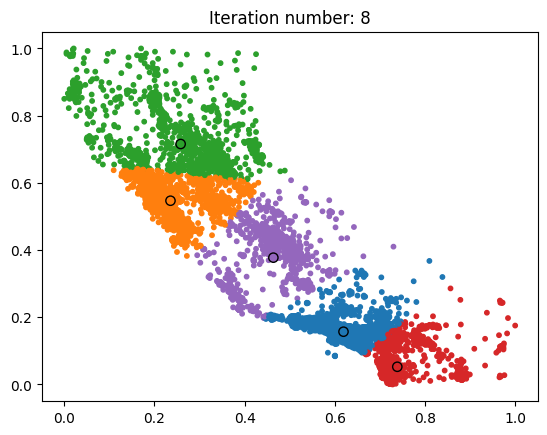

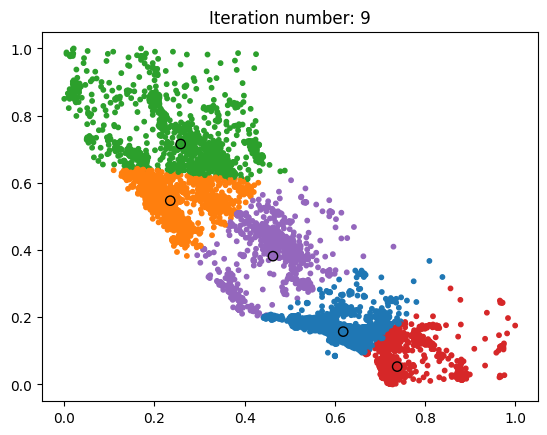

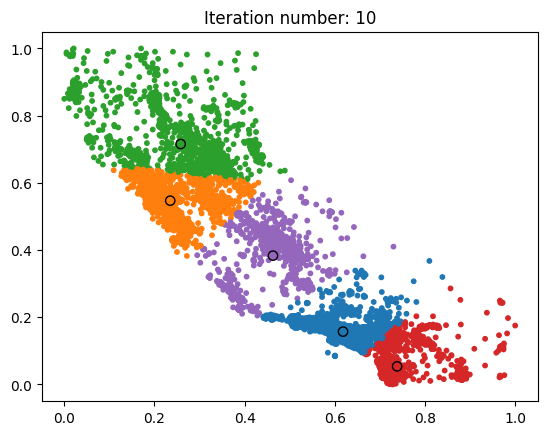

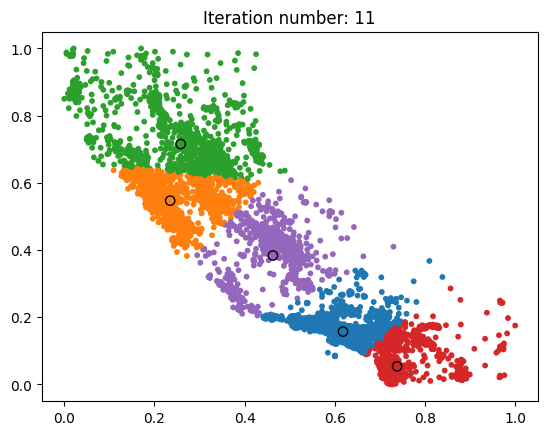

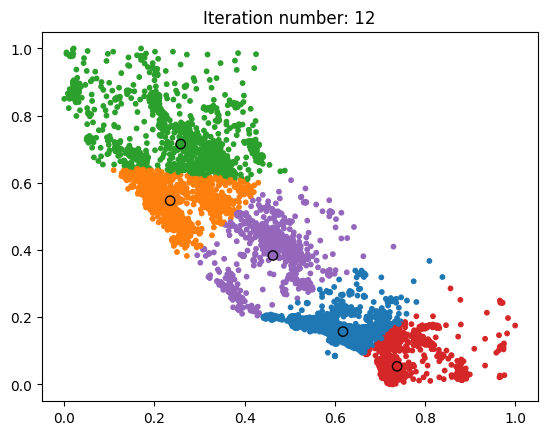

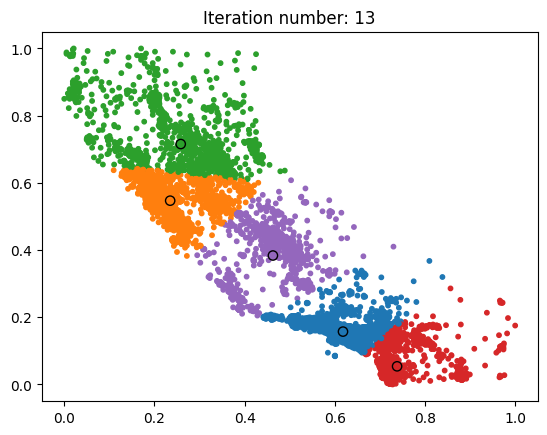

In [34]:
# Applying our k means to housing data
xy_housing = housing[['longitude','latitude']]
xy_housing = np.array(xy_housing)

kmeans_housing = KMeans(data = xy_housing, k = 5)
kmeans_housing.algorithm()